# Image Processsing (FFT)

In this laborartory experiment, we will employ Fast Fourier Transform to understand how edges are detected by computer vision systems.

## Image Preprocessing Exercise
Here, we'll demonstrate how image is preprocessed (e.g. text detection etc.)

In [1]:
# Import Necessary packages
import matplotlib.pyplot as plt
import numpy as np
import skimage

(1049, 1439, 4)


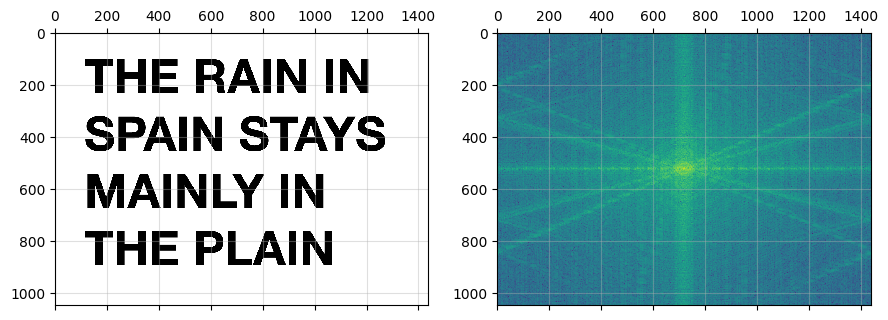

In [3]:
#Load the image file into a NumPy array
rain_spain = skimage.io.imread("RainSpain.png")

fig, axs = plt.subplots(1,2, figsize=(8,12))

# Show the raw image
axs[0].matshow(rain_spain)

# Compute the 2D FFT on the 4th channel of the image
# and use fftshift to shift the low-frequency components to the center of the matrix
spain_fft = np.fft.fftshift(np.fft.fft2(rain_spain[:,:,3]))

# Show its FFT (log intensity)
axs[1].matshow(np.log(1+np.abs(spain_fft)))

#Dimensions of the image
print(rain_spain.shape)

for i in axs:
    i.grid(True, alpha=0.4)
    # i.set(xtick=[], yticks=[])

fig.tight_layout()

Convert the image to grayscale

(1049, 1439)


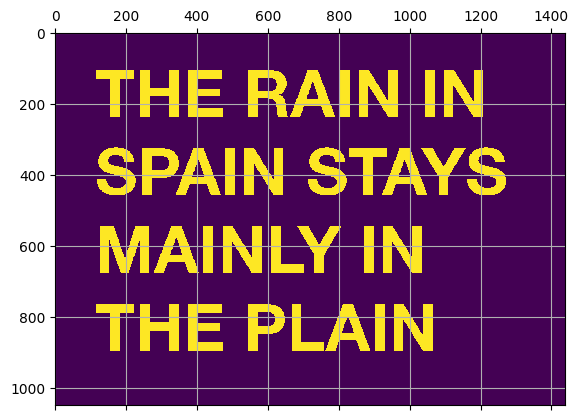

In [4]:
remove_alpha = skimage.color.rgba2rgb(rain_spain)
grayscale = skimage.color.rgb2gray(remove_alpha)
inverted = 255*(1 - grayscale)
grayscale_image = inverted
# Multiplied by 255 for later use

# Note that since the background is white, it will show up as >0
# in the grayscale version. Either query where the 0s are, or invert
# the image, to have the letters be 1's

print(grayscale_image.shape)
plt.matshow(grayscale_image == 255)
plt.grid(True)


Here, our goal is to find spots where there is an I beside N.

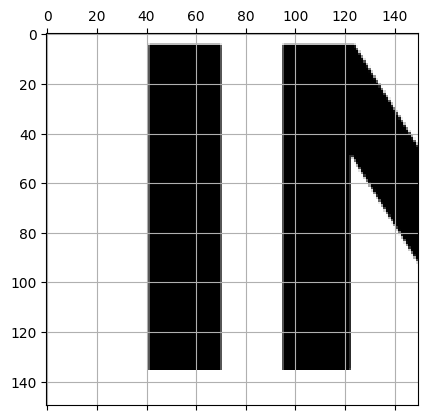

In [5]:
# Define the kernel
first_kernel = rain_spain[100:250, 1000:1150]
plt.matshow(first_kernel)
plt.grid(True)

For the kernel, we'll not label the inversion in its syntax. We define its grayscale inverted already.

Now, let's pad the kernel with zeroes

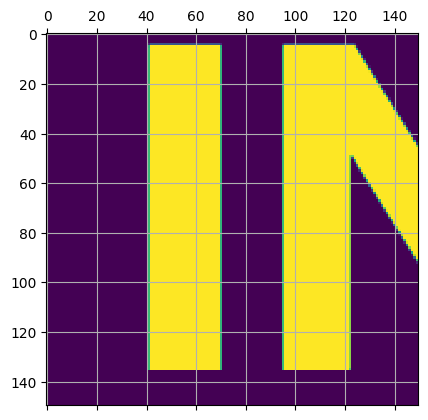

In [6]:
remove_alpha_ker = skimage.color.rgba2rgb(first_kernel)
fkernel = 1 - skimage.color.rgb2gray(remove_alpha_ker)
prprocessed_fkernel = 255*fkernel
plt.matshow(prprocessed_fkernel)
plt.grid(True)

Let's pad the preproceesed kernel with zeros until it reaches the dimensionality of the image.

In [7]:
def image_kernel(image, pre_kernel):
    # Define the shapes of image and pre_kernel
    M, N = image.shape
    m, n = pre_kernel.shape

    # For centering the kernel
    m_centered = m/2 + m%2
    n_centered = n/2 + n%2
    # Make the kernel
    kernel = np.zeros((M, N))
    kernel[0:m, 0:n] = pre_kernel
    kernel = np.roll(kernel, (-m_centered, -n_centered), axis=(0, 1))

    return kernel
    

In [8]:
prprocessed_fkernel.shape

(150, 150)

In [9]:
rain_spain.shape

(1049, 1439, 4)

(1049, 1439)


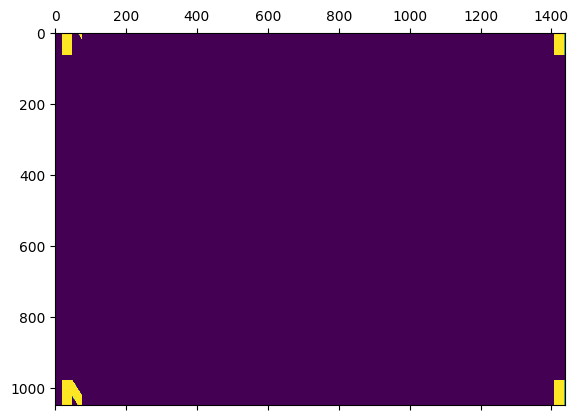

In [10]:
fkernel_fin = image_kernel(grayscale_image, prprocessed_fkernel) # Let's recover it
print(fkernel_fin.shape)
plt.matshow(fkernel_fin)

Now, that we have the kernel and image. We now Fourier Transform them

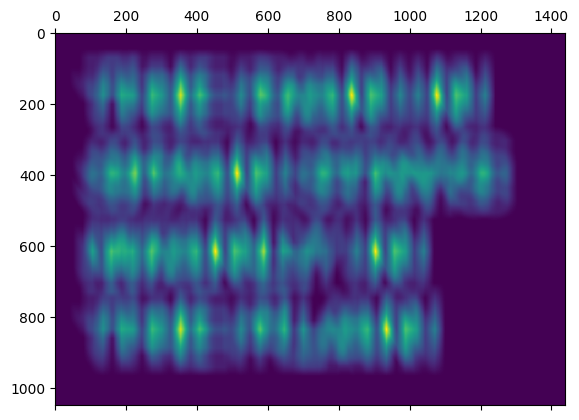

In [11]:
# For fft
from scipy.fft import fft, ifft

# Cross-correlate grayscale_image and its kernel
fourier = np.fft.fft2(grayscale_image)*np.conjugate(np.fft.fft2(fkernel_fin))
candidate_image = np.abs(np.fft.ifft2(fourier))
plt.matshow(candidate_image)

In [206]:
# Compute the gradient
def gradient(image, b):
    # Use Sobel Functions
    sobel_x = b*np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = sobel_x.T

    # Make them a proper array
    kernel_x = image_kernel(image, sobel_x)
    kernel_y = image_kernel(image, sobel_y)

    # Fourier Transform
    fourier_x = np.fft.fft2(image)*np.fft.fft2(kernel_x)
    # Pure convolution, not cross-correlation
    fourier_y = np.fft.fft2(image)*np.fft.fft2(kernel_y)

    # Inverse Fourier Transform
    gradient_x = np.abs(np.fft.ifft2(fourier_x))
    gradient_y = np.abs(np.fft.ifft2(fourier_y))

    # Return gradient
    gradient = np.sqrt(gradient_x**2 + gradient_y**2)
    return gradient

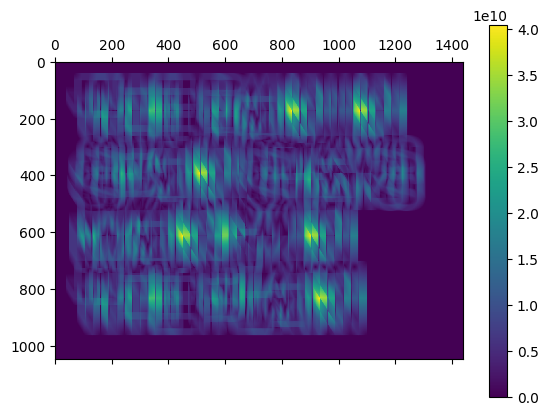

In [207]:
plt.matshow(gradient(candidate_image, 255))
# Apply it on our candidate image
plt.colorbar()

How about side to side?

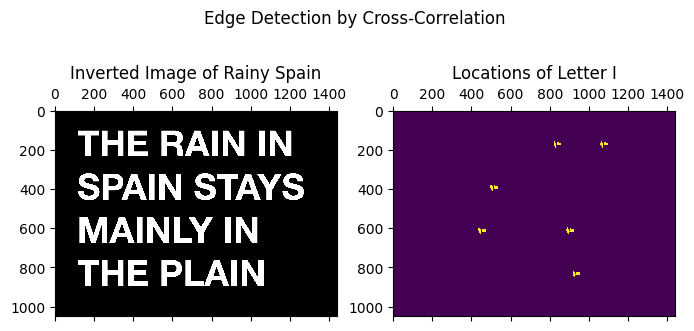

In [225]:
# Side to Side
fig, ax = plt.subplots(1, 2, figsize=(8,8))

ax[0].matshow(grayscale_image, cmap='gray')
ax[0].set_title("Inverted Image of Rainy Spain")
ax[1].matshow(gradient(candidate_image, 255) > 3.30e10) # where the 
ax[1].set_title("Locations of Letter I")
# nuisance peaks are eliminated
fig.suptitle("Edge Detection by Cross-Correlation", y=0.75)
fig.savefig("Part1.pdf")



Here, we can see that the gradient peaks are located when there are I's. It is because our kernel is defined to be with the I beside an N. The use of kernel is important as it decides where an "edge" is located. In this case, our grayscale I. Notice that in our kernel, there's a part of N beside it since at least in this image, all of I's are followed by N. Choosing I alone would mistake the vertical portions of other letters as I. We do not want it.

If one wishes, we define it differently, depending on the image. We proceed with a "real-world" image.

## Pook Aguinaldo

We repeat the process of preprocessing the image, and making kernels. This time, kernels are two-dimensional, and we'll finally use the gradient operation defined in the last part of the activity.
    

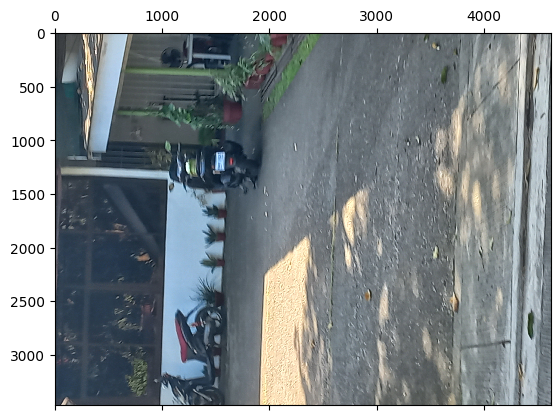

In [71]:
# We start with an image of my sample research work
pook_agui = skimage.io.imread("20260222_083639.jpg")

# Show the raw image
plt.matshow(pook_agui)

(3468, 4624)


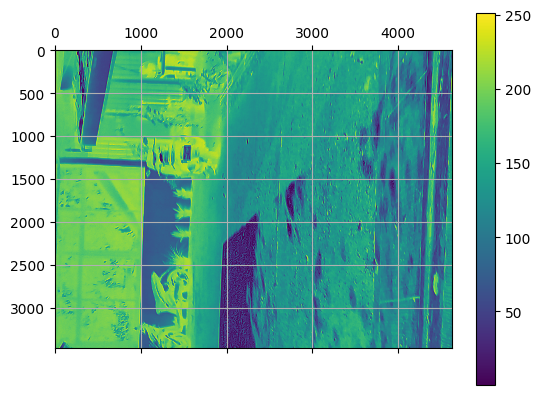

In [79]:
pook_gray = skimage.color.rgb2gray(pook_agui)
inverted = 255*(1 - pook_gray)
grayscale_pook = inverted

print(grayscale_pook.shape)
plt.matshow(grayscale_pook)
plt.colorbar()
plt.grid(True)

Convolution of the Sobel Functions with the image in order to calculate the gradient will be done. This is defined earlier when computing the gradient of an image in the cross-correlation part. The only difference is that, here in convolution part, the cross-correlation part is omitted as we're not comparing the image with a template.

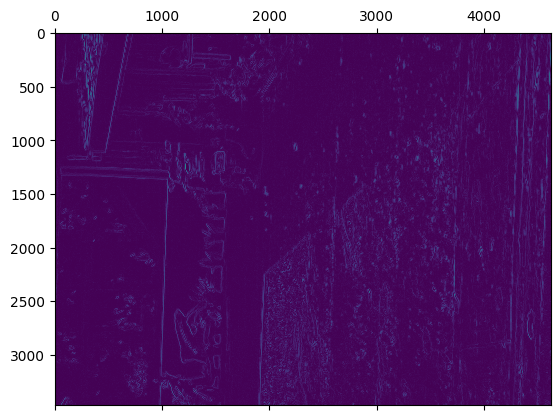

In [215]:
# The convolution of this part is done here
gradient_pook = gradient(grayscale_pook, 255) 
# 255 is chosen as scaling
plt.matshow(gradient_pook)

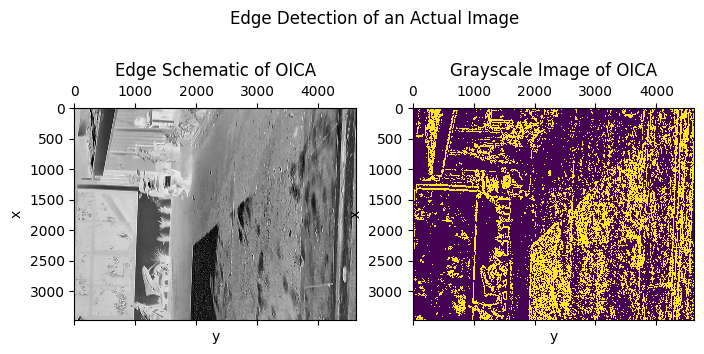

In [222]:
fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[1].matshow(gradient_pook > 3500) # To filter those of at least violet
ax[1].set_title("Grayscale Image of OICA")
ax[1].set_ylabel("x")
ax[1].set_xlabel("y")
ax[0].matshow(grayscale_pook, cmap='gray')
ax[0].set_title("Edge Schematic of OICA")
ax[0].set_ylabel("x")
ax[0].set_xlabel("y")
fig.suptitle("Edge Detection of an Actual Image", y=0.75)
fig.savefig("Part2.pdf")